# Diffusion Models para Geração de Imagens

Neste notebook, é implementado um pipeline de geração de imagens com **Stable Diffusion** da Hugging Face.

Em vez de usar o pipeline pronto (`StableDiffusionPipeline`), cada componente é carregado e conectado manualmente — o objetivo é tornar visível o que acontece por dentro do modelo.

**Referência:** [Stable Diffusion with 🧨 Diffusers](https://huggingface.co/blog/stable_diffusion#writing-your-own-inference-pipeline)

---

# 1 - Imports

In [1]:
import torch
from transformers import CLIPTextModel, CLIPTokenizer
from diffusers import AutoencoderKL, UNet2DConditionModel, DPMSolverMultistepScheduler
from tqdm.auto import tqdm
from PIL import Image

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


# 2 - Carregando os componentes do Stable Diffusion

O Stable Diffusion é um **Latent Diffusion Model** composto por três peças independentes:

| Componente | Função |
|------------|--------|
| **VAE** (Autoencoder Variacional) | Comprime a imagem 512×512 para um espaço latente 64×64 e reconstrói ao final |
| **U-Net** | Rede neural que aprende a remover ruído no espaço latente, guiada pelos embeddings de texto |
| **CLIP Text Encoder** | Transforma o prompt em um vetor numérico (77×768) que a U-Net usa para condicionar a geração |

Tudo é carregado em **float16** para reduzir o uso de VRAM na GPU sem perda perceptível de qualidade.

In [2]:
# modelo v1-5 em vez de v1-4
MODEL_ID = "runwayml/stable-diffusion-v1-5"


vae = AutoencoderKL.from_pretrained(MODEL_ID, subfolder="vae",torch_dtype=torch.float16)

tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-large-patch14")

text_encoder = CLIPTextModel.from_pretrained("openai/clip-vit-large-patch14", torch_dtype=torch.float16)

unet = UNet2DConditionModel.from_pretrained(MODEL_ID, subfolder="unet", torch_dtype=torch.float16)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

[transformers] CLIPTextModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...23}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

# 3 - Scheduler

O **scheduler** é o algoritmo que controla o ritmo do processo de denoising — ele decide quanto ruído remover em cada step.

É utilizado o `DPMSolverMultistepScheduler`, que gera imagens de alta qualidade com apenas **20 steps**, enquanto o scheduler padrão (PNDM) exigia ~50 steps.

> Mais steps = mais qualidade, porém mais tempo de processamento.

In [3]:
scheduler = DPMSolverMultistepScheduler.from_pretrained(MODEL_ID, subfolder="scheduler")

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

# 4 - Movendo os modelos para a GPU

Cada componente é um módulo PyTorch independente e precisa ser movido para a GPU separadamente com `.to(DEVICE)`.

In [4]:
DEVICE = "cuda"

vae.to(DEVICE)
text_encoder.to(DEVICE)
unet.to(DEVICE)

UNet2DConditionModel(
  (conv_in): Conv2d(4, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=320, out_features=1280, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=1280, out_features=1280, bias=True)
  )
  (down_blocks): ModuleList(
    (0): CrossAttnDownBlock2D(
      (attentions): ModuleList(
        (0-1): 2 x Transformer2DModel(
          (norm): GroupNorm(32, 320, eps=1e-06, affine=True)
          (proj_in): Conv2d(320, 320, kernel_size=(1, 1), stride=(1, 1))
          (transformer_blocks): ModuleList(
            (0): BasicTransformerBlock(
              (norm1): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
              (attn1): Attention(
                (to_q): Linear(in_features=320, out_features=320, bias=False)
                (to_k): Linear(in_features=320, out_features=320, bias=False)
                (to_v): Linear(in_features=320, out_fe

# 5 - Definindo os parâmetros de geração

| Parâmetro | Valor | Descrição |
|-----------|-------|-----------|
| `prompt` | texto | O que deve ser gerado |
| `negative_prompt` | texto | O que deve ser **evitado** na imagem |
| `height` / `width` | 512×512 | Tamanho da imagem de saída |
| `num_inference_steps` | 100 | Número de steps de denoising |
| `guidance_scale` | 7.5 | Força do condicionamento ao prompt — valores entre 7 e 8.5 são recomendados |
| `generator` | seed 42 | Garante reprodutibilidade — mesma seed = mesma imagem |

In [5]:
prompt = ["a futuristic city skyline at night, neon lights, reflections on wet streets"]
negative_prompt = ["daytime, blurry, low quality, ugly"]  # negative prompt

height, width = 512, 512
num_inference_steps = 100
guidance_scale = 7.5
generator = torch.manual_seed(42)
batch_size = len(prompt)

# 6 - Codificando o texto (Classifier-Free Guidance)

O **Classifier-Free Guidance (CFG)** é a técnica que permite ao modelo seguir o prompt de texto.

A cada step do denoising, a U-Net faz **duas previsões**:
- Uma condicionada no **prompt positivo** → "como seria a imagem seguindo o texto"
- Uma condicionada no **negative prompt** → "o que a imagem deve evitar"

A combinação das duas, controlada pelo `guidance_scale`, é o que guia a geração:

```
noise_final = noise_negativo + guidance_scale × (noise_positivo - noise_negativo)
```

Para evitar dois passes separados pela U-Net, os embeddings do negativo e do positivo são concatenados em um único batch.

In [6]:
# Prompt positivo
text_input = tokenizer(prompt, padding="max_length",
                       max_length=tokenizer.model_max_length, truncation=True, return_tensors="pt")

text_embeddings = text_encoder(text_input.input_ids.to(DEVICE))[0]

# negative prompt em vez de texto vazio
neg_input = tokenizer(negative_prompt, padding="max_length",
                      max_length=text_input.input_ids.shape[-1], return_tensors="pt")
neg_embeddings = text_encoder(neg_input.input_ids.to(DEVICE))[0]

# Concatena: [negativo, positivo] -> faz os dois passes de uma vez
text_embeddings = torch.cat([neg_embeddings, text_embeddings])

# 7 - Criando o ruído inicial no espaço latente

O ponto de partida da geração é **ruído gaussiano puro** no espaço latente.

O shape seria então: `(batch_size, 4, 64, 64)` — e **não** `(batch_size, 3, 512, 512)`.

Isso é o Latent Diffusion em ação: o processamento ocorre em um espaço 64 vezes menor que o espaço de pixels, o que torna o processo muito mais eficiente em memória.

O `scheduler.init_noise_sigma` escala o ruído para a magnitude esperada pelo scheduler no primeiro timestep.

In [7]:
latents = torch.randn(
      (batch_size, unet.config.in_channels, height // 8, width // 8),
      generator=generator).to(DEVICE).half()  # float16


scheduler.set_timesteps(num_inference_steps)
latents = latents * scheduler.init_noise_sigma

# 8 - Loop de denoising — o Reverse Process

Este é o coração do modelo. A cada iteração:

1. **O latente é duplicado** — uma cópia para o negativo, outra para o positivo (CFG)
2. **A U-Net prevê o ruído** presente no latente, condicionada nos embeddings de texto
3. **O CFG é aplicado** — as previsões negativa e positiva são combinadas com o `guidance_scale`
4. **O scheduler remove uma fração do ruído** e retorna o latente um pouco mais limpo

Após todos os steps, o latente evoluiu de ruído puro para uma representação coerente da cena descrita no prompt.

In [8]:
for t in tqdm(scheduler.timesteps):
    # Duplica o latente: um para o negativo, um para o positivo
    latent_input = torch.cat([latents] * 2)
    latent_input = scheduler.scale_model_input(latent_input, t)

    # U-Net prevê o ruído
    with torch.no_grad():
        noise_pred = unet(latent_input, t,
                            encoder_hidden_states=text_embeddings).sample

    # Classifier-free guidance: puxa em direção ao prompt, foge do negativo
    noise_neg, noise_pos = noise_pred.chunk(2)
    noise_pred = noise_neg + guidance_scale * (noise_pos - noise_neg)

    # Scheduler remove uma fração do ruído
    latents = scheduler.step(noise_pred, t, latents).prev_sample

  0%|          | 0/100 [00:00<?, ?it/s]

# 9 - Decodificando o latente -> imagem final

O latente final ainda não é uma imagem — é uma representação comprimida no espaço latente do VAE.

O fator `1 / 0.18215` é uma constante de normalização específica do VAE do Stable Diffusion, necessária para que o decoder receba os valores na escala correta.

O `vae.decode()` reconstrói a imagem 512×512 a partir do latente 64×64.

O tensor PyTorch é convertido para uma imagem PIL padrão (valores 0-255 em uint8).

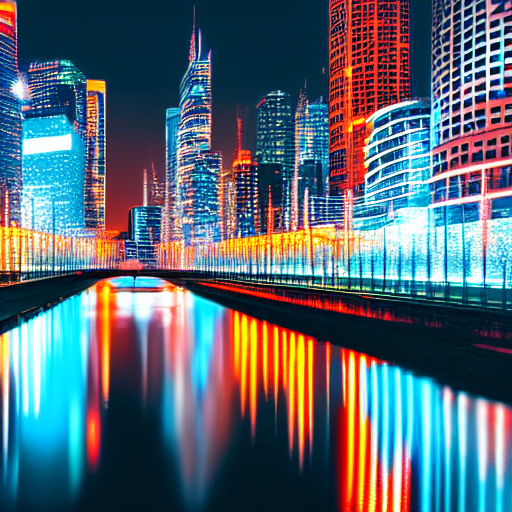

In [9]:
latents = 1 / 0.18215 * latents

with torch.no_grad():
    image = vae.decode(latents).sample

image = (image / 2 + 0.5).clamp(0, 1)
image = image.detach().cpu().permute(0, 2, 3, 1).float().numpy()
image = (image * 255).round().astype("uint8")
Image.fromarray(image[0])

# 10 - Interface interativa — Gradio

A célula abaixo cria uma interface onde é possível digitar um prompt, ajustar os parâmetros e acompanhar a geração da imagem **step a step** em tempo real.

A função usa `yield` em vez de `return` — o Gradio entende isso como um gerador e atualiza a imagem a cada step do denoising. Os primeiros steps mostram ruído puro, e progressivamente a imagem vai tomando forma — o reverse process acontecendo visualmente na tela.

In [13]:
!pip install gradio -q

import gradio as gr
import random

def gerar_com_preview(prompt, negative_prompt, guidance_scale, num_steps, seed, randomize_seed):
    if randomize_seed:
        seed = random.randint(0, 2**32 - 1)

    gen = torch.manual_seed(int(seed))

    # Codifica os prompts
    text_input = tokenizer(
        [prompt], padding="max_length",
        max_length=tokenizer.model_max_length,
        truncation=True, return_tensors="pt"
    )
    text_emb = text_encoder(text_input.input_ids.to(DEVICE))[0]

    neg_input = tokenizer(
        [negative_prompt], padding="max_length",
        max_length=text_input.input_ids.shape[-1],
        return_tensors="pt"
    )
    neg_emb = text_encoder(neg_input.input_ids.to(DEVICE))[0]

    text_embeddings = torch.cat([neg_emb, text_emb])

    # Ruído inicial
    latents = torch.randn(
        (1, unet.config.in_channels, 512 // 8, 512 // 8),
        generator=gen
    ).to(DEVICE).half()

    scheduler.set_timesteps(int(num_steps))
    latents = latents * scheduler.init_noise_sigma

    import time

    # Loop de denoising com preview a cada 2 steps
    for i, t in enumerate(scheduler.timesteps):
        latent_input = torch.cat([latents] * 2)
        latent_input = scheduler.scale_model_input(latent_input, t)

        with torch.no_grad():
            noise_pred = unet(latent_input, t,
                              encoder_hidden_states=text_embeddings).sample

        noise_neg, noise_pos = noise_pred.chunk(2)
        noise_pred = noise_neg + guidance_scale * (noise_pos - noise_neg)
        latents = scheduler.step(noise_pred, t, latents).prev_sample

        # Decodifica a cada step
        with torch.no_grad():
            preview = vae.decode(1 / 0.18215 * latents).sample

        preview = (preview / 2 + 0.5).clamp(0, 1)
        preview = preview.detach().cpu().permute(0, 2, 3, 1).float().numpy()
        preview = (preview * 255).round().astype("uint8")

        yield Image.fromarray(preview[0]), int(seed), f"Step {i+1} / {int(num_steps)}"
        time.sleep(0.5)  # aguarda o Gradio enviar o frame antes do próximo step


with gr.Blocks() as demo:
    gr.Markdown("# 🎨 Gerador de Imagens — Stable Diffusion")

    with gr.Row():
        with gr.Column():
            prompt = gr.Textbox(
                label="Prompt",
                value="a futuristic city skyline at night, neon lights, reflections on wet streets",
                lines=2
            )
            negative_prompt = gr.Textbox(
                label="Negative Prompt",
                value="daytime, blurry, low quality, ugly",
                lines=2
            )
            with gr.Row():
                steps = gr.Slider(5, 50, value=20, step=5, label="Steps")
                guidance = gr.Slider(1, 15, value=7.5, step=0.5, label="Guidance (CFG)")
            with gr.Row():
                seed = gr.Number(value=42, label="Seed", precision=0)
                randomize = gr.Checkbox(label="Seed aleatória", value=False)
            btn = gr.Button("Gerar imagem", variant="primary")

        with gr.Column():
            output_image = gr.Image(label="Progresso da geração", type="pil")
            output_seed = gr.Number(label="Seed utilizada", interactive=False)
            progress_text = gr.Textbox(label="", interactive=False)

    btn.click(
        fn=gerar_com_preview,
        inputs=[prompt, negative_prompt, guidance, steps, seed, randomize],
        outputs=[output_image, output_seed, progress_text],
    )

demo.queue()
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b08c4b1eab6ec37d21.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
